# Figure 6a3 | MHA versus hybrid MHA + Mamba-2

**Core conclusion examined:** a variant with lower held-out PPL should show an earlier rise in position-standardized top-5% functional correlation (FC).

**Within-group comparison:** Only `ModelConfig.mixer_pattern` changes. Mamba-2 comes from the official `mamba_ssm.Mamba2`; no surrogate SSM is allowed.

The notebook is intentionally thin. Data handling, architectures, paired initialization, training, FC estimation, descriptive paired statistics and publication exports live in the shared `fc_compare` package so the four comparisons cannot silently drift apart.

> **Rerun note:** Saved output cells may contain earlier diagnostics. Rerunning uses the current frozen analysis and writes to the configured `results_v3/` directory.

Training displays a per-seed progress bar with the latest paired losses.

## Preregistered measurement

- Corpus: the three local WikiText-2 splits; vocabulary is built from training only.
- PPL: complete validation/test splits, token-weighted cross-entropy, best validation checkpoint.
- FC units: the D-dimensional effective input to each selected block. `FC_LAYER = 'all'` computes FC independently in every layer and then takes their equal-weight mean; use a zero-based integer for one layer. For DHC, each tap is the actually routed branch input, not the mean of four streams.
- FC profile: fixed validation sequences; each feature is z-scored across sequences within each token position before concatenation.
- Primary FC statistic: mean of the largest signed 5% off-diagonal Pearson correlations.
- Earlier rise: first three-checkpoint sustained increase of at least 0.03 above step 0.
- Reporting: paired estimates and bootstrap confidence intervals are saved without automatic pass/fail decisions.
- Figure panels: absolute top-n% FC mean, its change from initialization, and validation PPL. All panels are drawn whenever training completes.

In [1]:
from dataclasses import replace
from pathlib import Path
import json
import sys

HERE = Path.cwd().resolve()
if not (HERE / 'fc_compare').is_dir():
    raise RuntimeError('Start Jupyter with FC_compare as the working directory.')
sys.path.insert(0, str(HERE))

from fc_compare import paper_config, run_comparison, smoke_config


In [2]:
GROUP = 'a3'
DATA_DIR = Path('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2')
MODE = 'paper'  # use 'smoke' only to test the pipeline; smoke results are not scientific evidence
FC_LAYER = 7  # 'all' averages per-layer FC; use a zero-based integer for one layer
OUTPUT_DIR = HERE / 'results' / 'a3'

factory = paper_config if MODE == 'paper' else smoke_config
spec, data, train, fc = factory(GROUP, DATA_DIR)
fc = replace(fc, layer_selection=FC_LAYER)
print(spec)
print(data)
print(train)
print(fc)


ComparisonSpec(key='a3', title='Sequence mixer', baseline_label='MHA', optimized_label='Hybrid MHA + Mamba-2', baseline=ModelConfig(vocab_size=0, d_model=256, n_heads=8, d_ff=1024, n_layers=8, dropout=0.1, position='rope', norm_position='pre', residual='standard', mixer_pattern=('mha', 'mha', 'mha', 'mha', 'mha', 'mha', 'mha', 'mha'), rope_base=10000.0, hc_streams=4, hc_dynamic_scale=0.02, hc_tanh=True, hc_adaptive_readout=True, mamba_d_state=64, mamba_d_conv=4, mamba_expand=4, mamba_headdim=64), optimized=ModelConfig(vocab_size=0, d_model=256, n_heads=8, d_ff=1024, n_layers=8, dropout=0.1, position='rope', norm_position='pre', residual='standard', mixer_pattern=('mamba2', 'mamba2', 'mamba2', 'mha', 'mamba2', 'mamba2', 'mamba2', 'mha'), rope_base=10000.0, hc_streams=4, hc_dynamic_scale=0.02, hc_tanh=True, hc_adaptive_readout=True, mamba_d_state=64, mamba_d_conv=4, mamba_expand=4, mamba_headdim=64), allowed_model_differences=('mixer_pattern',), hypothesis='The hybrid mixer has lower hel

In [3]:
result = run_comparison(
    spec=spec,
    data=data,
    train=train,
    fc=fc,
    output_dir=OUTPUT_DIR,
)
print(json.dumps(result['aggregate'], indent=2, ensure_ascii=False))


/mnt/Data16T/home/haichao/miniconda3/envs/neuroai/lib/python3.12/site-packages/mamba_ssm/utils/determinism.py:73: UserWarning: Deterministic mode: set TRITON_CACHE_AUTOTUNING=1 for cached autotuning.
  warnings.warn(msg)


a3 seed 11 (1/5):   0%|          | 0/500 [00:00<?, ?step/s]

/mnt/Data16T/home/haichao/miniconda3/envs/neuroai/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:114.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


a3 seed 22 (2/5):   0%|          | 0/500 [00:00<?, ?step/s]

a3 seed 33 (3/5):   0%|          | 0/500 [00:00<?, ?step/s]

a3 seed 44 (4/5):   0%|          | 0/500 [00:00<?, ?step/s]

a3 seed 55 (5/5):   0%|          | 0/500 [00:00<?, ?step/s]

{
  "n_seeds": 5,
  "ppl_comparison": {
    "estimand": "paired log(test PPL optimized / baseline), best validation checkpoint",
    "paired_values": [
      -0.09599490359627527,
      -0.10645470007616975,
      -0.09551381418429017,
      -0.10332278190986699,
      -0.10338960872327974
    ],
    "median": -0.10332278190986699,
    "bootstrap_ci": [
      -0.10645470007616975,
      -0.09551381418429017
    ],
    "paired_percent_changes": [
      -9.15313540201006,
      -10.098422741516188,
      -9.109419422535659,
      -9.816416979550713,
      -9.822443459658636
    ],
    "median_percent_change": -9.816416979550713,
    "percent_change_bootstrap_ci": [
      -10.098422741516188,
      -9.109419422535659
    ]
  },
  "fc_timing": {
    "estimand": "optimized minus baseline onset step; negative means earlier",
    "paired_values": [
      -20.0,
      -20.0,
      -10.0,
      -20.0,
      -20.0
    ],
    "median": -20.0,
    "bootstrap_ci": [
      -20.0,
      -10.0
    ],


Loaded 5 seed summaries:
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/seed_11/summary.json
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/seed_22/summary.json
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/seed_33/summary.json
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/seed_44/summary.json
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/seed_55/summary.json

Regenerated files:
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/compare_methods_FC_curve/codex/results/a3/a3_sequence_mixer.svg
  /mnt/Data16T/Data/haichao/code/AI_connectom/story/st

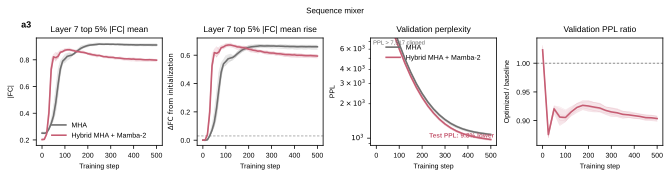

In [5]:
import importlib
import json
from pathlib import Path

from IPython.display import SVG, display
from fc_compare import paper_config
import fc_compare.plotting as plotting

# 重新加载刚修改的 plotting.py，避免 Jupyter 使用旧的缓存版本
plotting = importlib.reload(plotting)

output_dir = Path(OUTPUT_DIR)

# 只读取实验配置标签，不会加载数据集或训练模型
spec = paper_config(GROUP, DATA_DIR)[0]

# 读取已有的聚合统计
aggregate_path = output_dir / "aggregate_summary.json"
if not aggregate_path.is_file():
    raise FileNotFoundError(f"Missing: {aggregate_path}")

aggregate = json.loads(aggregate_path.read_text(encoding="utf-8"))

# 读取所有已有 seed 的训练结果
summary_paths = sorted(output_dir.glob("seed_*/summary.json"))
if not summary_paths:
    raise FileNotFoundError(f"No seed summaries found in: {output_dir}")

summaries = [
    json.loads(path.read_text(encoding="utf-8"))
    for path in summary_paths
]

print(f"Loaded {len(summaries)} seed summaries:")
for path in summary_paths:
    print(" ", path)

# 覆盖生成新的 ratio 版本图片和 source_data.csv
figure_paths = plotting.plot_group(
    spec=spec,
    summaries=summaries,
    aggregate=aggregate,
    output_stem=output_dir / "figure",
)

print("\nRegenerated files:")
for path in figure_paths:
    print(" ", path)

# 在 notebook 中显示新图
display(SVG(filename=str(figure_paths[0])))